<a href="https://colab.research.google.com/github/pcmouadji-dot/machine-learning/blob/main/Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as skl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import seaborn as sns

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,-1.424569,-1.738999,-0.434801,0,1
1,-1.281035,-1.738999,1.195704,0,1
2,-1.352802,-1.700830,-1.715913,1,0
3,-1.137502,-1.700830,1.040418,1,0
4,-0.563369,-1.662660,-0.395980,1,0
...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,1,0
196,0.441365,2.497807,-0.861839,1,0
197,-0.491602,2.497807,0.923953,0,1
198,-0.491602,2.917671,-1.250054,0,1


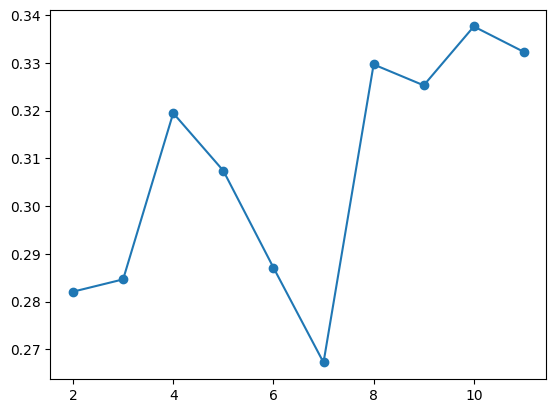

In [ ]:
from sklearn.metrics.cluster import silhouette_score
from numpy.random.mtrand import rand
df=pd.read_csv("Mall_Customers.csv")
id=df["CustomerID"]
df=df.drop(columns=["CustomerID"])
df=pd.get_dummies(df,prefix="Gender",columns=['Gender'],dtype=int)

scale=StandardScaler()
to_scale=['Age','Annual Income (k$)','Spending Score (1-100)']
df[to_scale]=scale.fit_transform(df[to_scale])
display(df)
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=18)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)
#plt.plot(range(1,11),wcss,marker="o")#i think this is a bad methode because it is a little bit harde to get where is the elbow point
sil=[]
for i in range(2,12):
  kmeans=KMeans(n_clusters=i,random_state=18)
  label=kmeans.fit_predict(df)
  score=silhouette_score(df,label)
  sil.append(score)
plt.plot(range(2,12),sil,marker="o")# althow 0.34 is bad but i don't know how to make it better.
#k=10


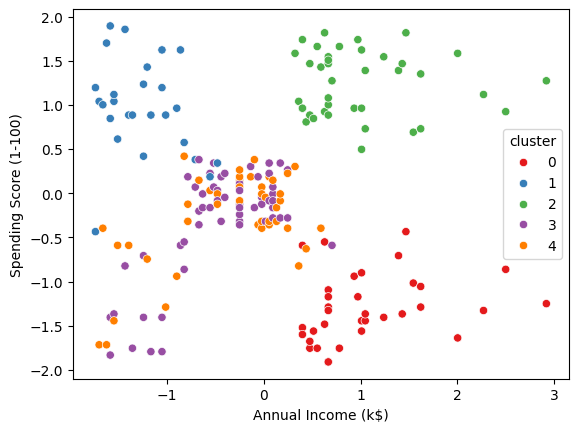

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=18)
label=kmeans.fit_predict(df)
df['cluster']=label
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',palette='Set1')
plt.show()
sub=pd.DataFrame({"ID":id,
                  "TARGET":label})
sub.to_csv("submision.csv",index=False)


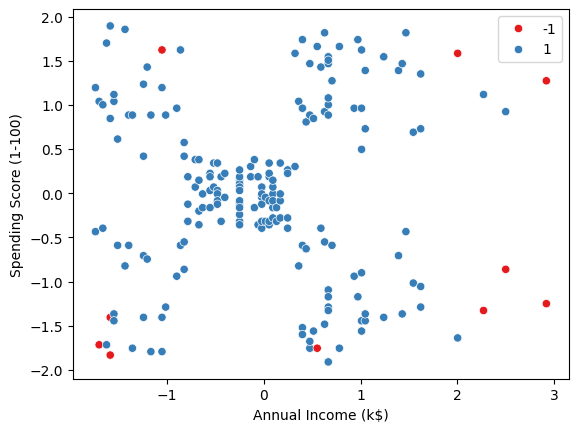

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as skl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import seaborn as sns
from sklearn.ensemble import IsolationForest
icl=IsolationForest(contamination=0.05)
icl.fit(df)
predictions=icl.predict(df)
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue=predictions,palette='Set1')
plt.show()